# Demand Forecasting for Inventory Planning — UCI Online Retail II

**Goal.** Forecast **aggregate unit demand** for inventory planning on the
UCI Online Retail II dataset (id 502), using the same two-track design as the
Superstore notebook:

1. **Part 1 — PyCaret 4.x time-series survey (MASE-ranked)** → native
   reimplementation of the winner with residual diagnostics + prediction
   intervals.
2. **Part 2 — Google TimesFM 2.5 zero-shot** (history as inference context,
   no gradient updates on this series).

**Business framing.** Online retail demand is intermittent at the SKU level
and lumpy at the store level. Planning safety stock from a total-units
forecast still helps with warehouse capacity, inbound purchase volume, and
cash tied in inventory — provided we respect time order and uncertainty.

License: **CC BY 4.0** (UCI). Same cleaning rules as the churn/segmentation
projects: drop cancellations (`Invoice` starting with `C`) and non-positive
Quantity/Price before aggregating.

## 1. Setup

Shared `demand-forecast-project` kernel (uv-managed). PyCaret 4.x OOP API;
TimesFM 2.5 via `timesfm[torch]`.

In [1]:
from __future__ import annotations

import io
import sys
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch

try:
    from IPython import get_ipython
    from IPython.display import display

    IN_IPYTHON = get_ipython() is not None
except ImportError:
    IN_IPYTHON = False

    def display(obj):
        print(obj)

import matplotlib

if not IN_IPYTHON:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_plot() -> None:
    plt.tight_layout()
    if IN_IPYTHON:
        plt.show()
    else:
        plt.show(block=False)
        plt.close("all")


from pmdarima import auto_arima
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python        : {sys.version.split()[0]}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"torch         : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

import pycaret
import timesfm

print(f"pycaret       : {pycaret.__version__}")
print(f"timesfm 2.5   : TimesFM_2p5_200M_torch={hasattr(timesfm, 'TimesFM_2p5_200M_torch')}")
print(f"Kernel target : demand-forecast-project")
assert pycaret.__version__.startswith("4."), "Expected PyCaret 4.x OOP API"
assert hasattr(timesfm, "TimesFM_2p5_200M_torch"), "TimesFM 2.5 torch class missing"

Python        : 3.13.13
pandas        : 2.3.3
numpy         : 2.4.6
torch         : 2.13.0+cu130 | CUDA: True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
pycaret       : 4.0.0a8
timesfm 2.5   : TimesFM_2p5_200M_torch=True
Kernel target : demand-forecast-project


## 2. Data acquisition — UCI Online Retail II (id 502)

UK-based online giftware retailer transactions across ~2009–2011. Columns
include Invoice, StockCode, Description, Quantity, InvoiceDate, Price,
Customer ID, Country. We forecast **sum(Quantity)** over time after cleaning.

Spec path is `ucimlrepo.fetch_ucirepo(id=502)`. On many environments UCI
currently marks this dataset as **not available for Python import** via
`ucimlrepo`, so we fall back to the **official UCI static zip** of the same
dataset (CC BY 4.0) and load both Excel sheets (2009–2010 and 2010–2011).
No third-party mirror.

In [2]:
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
# Resolve project-root data/ whether cwd is repo root or notebooks/
_root_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (p for p in _root_candidates if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
LOCAL_ZIP = DATA_DIR / "online_retail_ii.zip"
print(f"Project root for data cache: {PROJECT_ROOT}")

df_raw = None
ucimlrepo_status = None

try:
    from ucimlrepo import fetch_ucirepo

    print("Trying ucimlrepo.fetch_ucirepo(id=502)…")
    retail_ii = fetch_ucirepo(id=502)
    df_raw = retail_ii.data.features.copy()
    ucimlrepo_status = "ok"
    print("ucimlrepo path succeeded")
except Exception as exc:  # noqa: BLE001 — expected on many envs for id 502
    ucimlrepo_status = f"FAILED: {type(exc).__name__}: {exc}"
    print(f"ucimlrepo path: {ucimlrepo_status}")
    print(f"Falling back to official UCI zip: {UCI_ZIP_URL}")

    if LOCAL_ZIP.exists() and LOCAL_ZIP.stat().st_size > 1_000_000:
        print(f"Using cached zip: {LOCAL_ZIP} ({LOCAL_ZIP.stat().st_size:,} bytes)")
        zip_bytes = LOCAL_ZIP.read_bytes()
    else:
        resp = requests.get(UCI_ZIP_URL, timeout=300)
        resp.raise_for_status()
        zip_bytes = resp.content
        LOCAL_ZIP.write_bytes(zip_bytes)
        print(f"Cached zip to {LOCAL_ZIP} ({len(zip_bytes):,} bytes)")

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        print("Zip contents:", zf.namelist())
        # Official archive ships online_retail_II.xlsx
        xlsx_name = next(
            (n for n in zf.namelist() if n.lower().endswith((".xlsx", ".xls"))),
            None,
        )
        if xlsx_name is None:
            raise FileNotFoundError(f"No Excel file in zip: {zf.namelist()}")
        with zf.open(xlsx_name) as fh:
            xl = pd.ExcelFile(fh)
            print("Sheets:", xl.sheet_names)
            frames = [xl.parse(sheet) for sheet in xl.sheet_names]
            df_raw = pd.concat(frames, ignore_index=True)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"ucimlrepo_status: {ucimlrepo_status}")
display(df_raw.head(3))
display(df_raw.dtypes.to_frame("dtype"))

Project root for data cache: /home/ahmad/AI/Demand Forecasting for Inventory Planning
Trying ucimlrepo.fetch_ucirepo(id=502)…


ucimlrepo path: FAILED: DatasetNotFoundError: "Online Retail II" dataset (id=502) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true
Falling back to official UCI zip: https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip
Using cached zip: /home/ahmad/AI/Demand Forecasting for Inventory Planning/data/online_retail_ii.zip (45,622,418 bytes)
Zip contents: ['online_retail_II.xlsx']
Sheets: ['Year 2009-2010', 'Year 2010-2011']


Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
ucimlrepo_status: FAILED: DatasetNotFoundError: "Online Retail II" dataset (id=502) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


## 3. Cleaning + exploratory analysis

Cancellations and returns distort demand. Drop invoice numbers starting with
`C`, then non-positive Quantity/Price — the same gate used in related
portfolio projects on this dataset.

Cancellation rows (Invoice starts with C): 19,494
Non-positive Quantity: 22,950
Non-positive Price: 6,207
Null InvoiceDate: 0


Kept 1,041,670 / 1,067,371 rows after cleaning
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Calendar days spanned: 739
Days with zero orders: 135 (18.3%)
Mean orders/day: 1409.57 | CV: 0.73


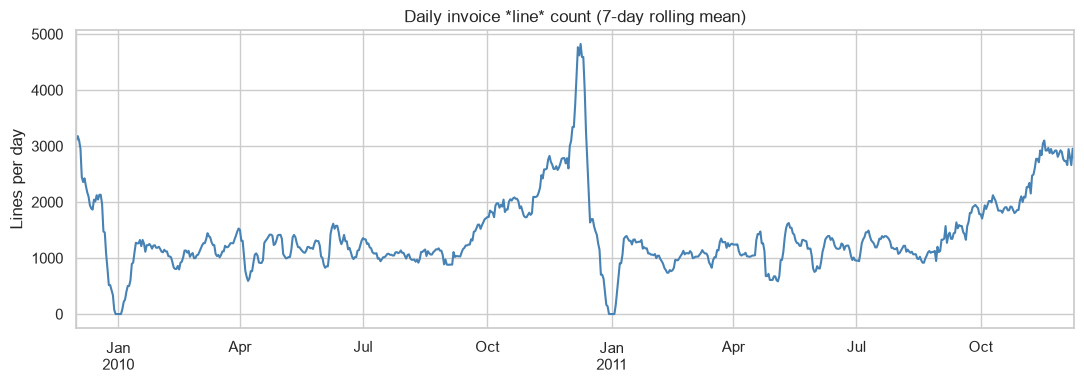

In [3]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Harmonize column names across ucimlrepo versions
colmap = {}
for c in df.columns:
    cl = c.lower().replace(" ", "")
    if cl in {"invoice", "invoiceno"}:
        colmap[c] = "Invoice"
    elif cl in {"invoicedate"}:
        colmap[c] = "InvoiceDate"
    elif cl in {"quantity"}:
        colmap[c] = "Quantity"
    elif cl in {"price", "unitprice"}:
        colmap[c] = "Price"
    elif cl in {"customerid", "customer_id"}:
        colmap[c] = "Customer ID"
    elif cl in {"country"}:
        colmap[c] = "Country"
    elif cl in {"stockcode"}:
        colmap[c] = "StockCode"
    elif cl in {"description"}:
        colmap[c] = "Description"
df = df.rename(columns=colmap)

required = {"Invoice", "InvoiceDate", "Quantity", "Price"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing expected columns after rename: {missing}. Have={list(df.columns)}")

n0 = len(df)
df["Invoice"] = df["Invoice"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

cancel_mask = df["Invoice"].str.startswith("C", na=False)
print(f"Cancellation rows (Invoice starts with C): {cancel_mask.sum():,}")
print(f"Non-positive Quantity: {(df['Quantity'] <= 0).sum():,}")
print(f"Non-positive Price: {(df['Price'] <= 0).sum():,}")
print(f"Null InvoiceDate: {df['InvoiceDate'].isna().sum():,}")

df = df.loc[~cancel_mask].copy()
df = df.dropna(subset=["InvoiceDate", "Quantity", "Price"])
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()
print(f"Kept {len(df):,} / {n0:,} rows after cleaning")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

daily_orders = df.groupby(df["InvoiceDate"].dt.normalize()).size()
full_daily_idx = pd.date_range(daily_orders.index.min(), daily_orders.index.max(), freq="D")
daily_orders = daily_orders.reindex(full_daily_idx, fill_value=0)
print(f"Calendar days spanned: {len(daily_orders)}")
print(
    f"Days with zero orders: {(daily_orders == 0).sum()} "
    f"({100 * (daily_orders == 0).mean():.1f}%)"
)
print(
    f"Mean orders/day: {daily_orders.mean():.2f} | "
    f"CV: {daily_orders.std() / daily_orders.mean():.2f}"
)

fig, ax = plt.subplots()
daily_orders.rolling(7, min_periods=1).mean().plot(ax=ax, color="steelblue")
ax.set_title("Daily invoice *line* count (7-day rolling mean)")
ax.set_ylabel("Lines per day")
show_plot()

### 3.1 Candidate granularities: daily vs weekly unit demand

Decide grain from **observed** sparsity and variability — do not assume weekly.

,grain,n,mean,std,cv,pct_zero,min,max,start,end
0,daily,739,15453.728011,13431.098791,0.869117,18.267930,0.0,125534.0,2009-12-01,2011-12-09
1,weekly,106,107738.726415,46139.176735,0.428251,1.886792,0.0,248485.0,2009-12-06,2011-12-11


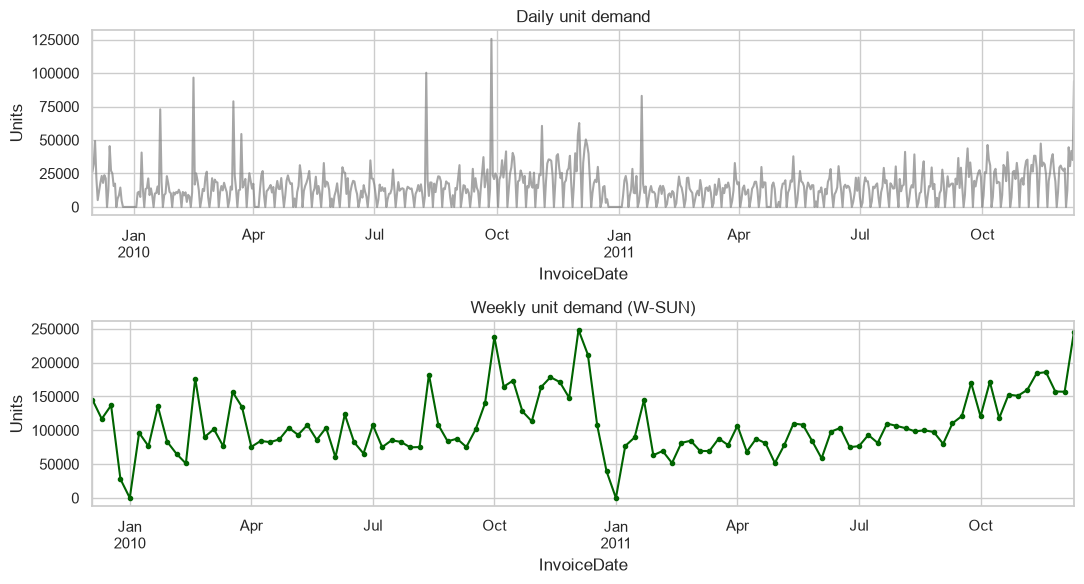


>>> GRANULARITY DECISION: WEEKLY
Daily series has 18.3% zero-demand days and CV=0.87 vs weekly CV=0.43. Weekly aggregation is more stable for planning.
Series length: 106 | 2009-12-06 → 2011-12-11


In [4]:
demand_daily = (
    df.groupby(df["InvoiceDate"].dt.normalize())["Quantity"]
    .sum()
    .rename("demand")
    .asfreq("D", fill_value=0)
    .sort_index()
)
demand_weekly = (
    df.set_index("InvoiceDate")["Quantity"]
    .resample("W-SUN")
    .sum()
    .rename("demand")
    .sort_index()
)
demand_weekly = demand_weekly.loc[
    demand_weekly.ne(0).idxmax() : demand_weekly.ne(0)[::-1].idxmax()
]


def series_profile(s: pd.Series, name: str) -> dict:
    s = s.astype(float)
    return {
        "grain": name,
        "n": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)),
        "cv": float(s.std(ddof=1) / s.mean()) if s.mean() else np.nan,
        "pct_zero": float((s == 0).mean() * 100),
        "min": float(s.min()),
        "max": float(s.max()),
        "start": str(s.index.min().date()),
        "end": str(s.index.max().date()),
    }


profiles = pd.DataFrame([
    series_profile(demand_daily, "daily"),
    series_profile(demand_weekly, "weekly"),
])
display(profiles)

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
demand_daily.plot(ax=axes[0], color="gray", alpha=0.7, title="Daily unit demand")
axes[0].set_ylabel("Units")
demand_weekly.plot(
    ax=axes[1], color="darkgreen", marker="o", ms=3, title="Weekly unit demand (W-SUN)"
)
axes[1].set_ylabel("Units")
show_plot()

daily_pct_zero = profiles.loc[profiles.grain == "daily", "pct_zero"].iloc[0]
daily_cv = profiles.loc[profiles.grain == "daily", "cv"].iloc[0]
weekly_cv = profiles.loc[profiles.grain == "weekly", "cv"].iloc[0]

if daily_pct_zero > 15 or daily_cv > weekly_cv * 1.15:
    GRAIN = "weekly"
    y_full = demand_weekly.copy()
    SEASONAL_PERIOD = 52
    decision_reason = (
        f"Daily series has {daily_pct_zero:.1f}% zero-demand days and CV={daily_cv:.2f} "
        f"vs weekly CV={weekly_cv:.2f}. Weekly aggregation is more stable for planning."
    )
else:
    GRAIN = "daily"
    y_full = demand_daily.copy()
    SEASONAL_PERIOD = 7
    decision_reason = (
        f"Daily series is dense enough (zero days={daily_pct_zero:.1f}%, CV={daily_cv:.2f}); "
        "keeping daily grain."
    )

print(f"\n>>> GRANULARITY DECISION: {GRAIN.upper()}")
print(decision_reason)
print(f"Series length: {len(y_full)} | {y_full.index.min().date()} → {y_full.index.max().date()}")

### 3.2 Trend, seasonality, stationarity

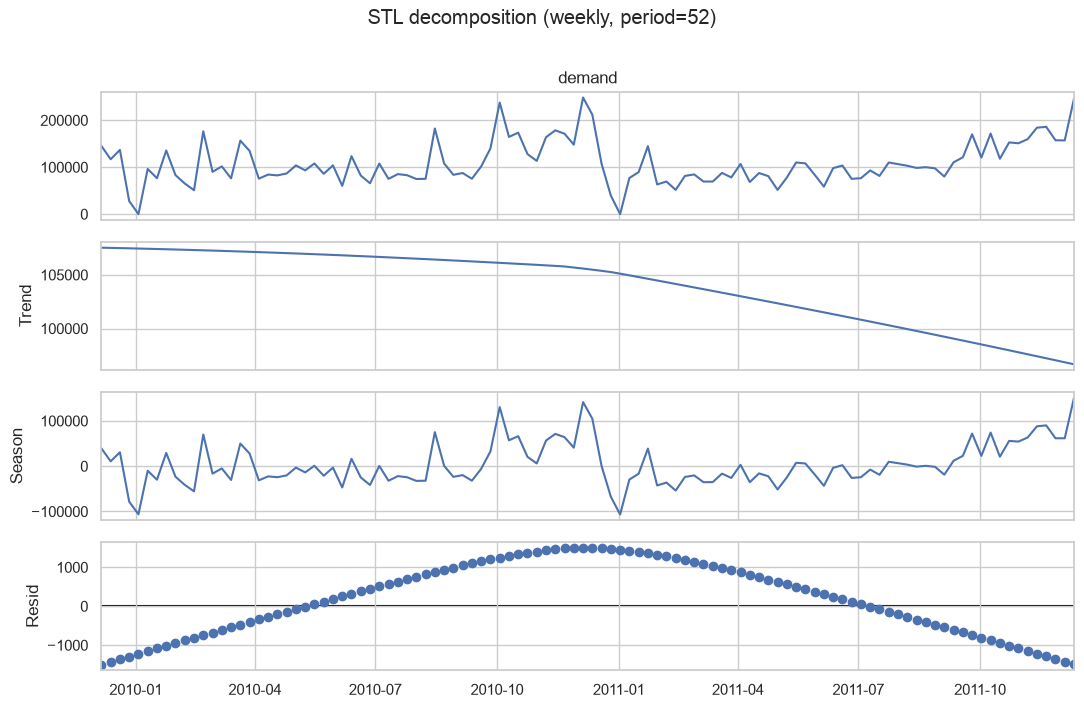

ADF statistic=-5.0532, p-value=1.74e-05
Reject H0 of unit root → series looks stationary (at 5%).


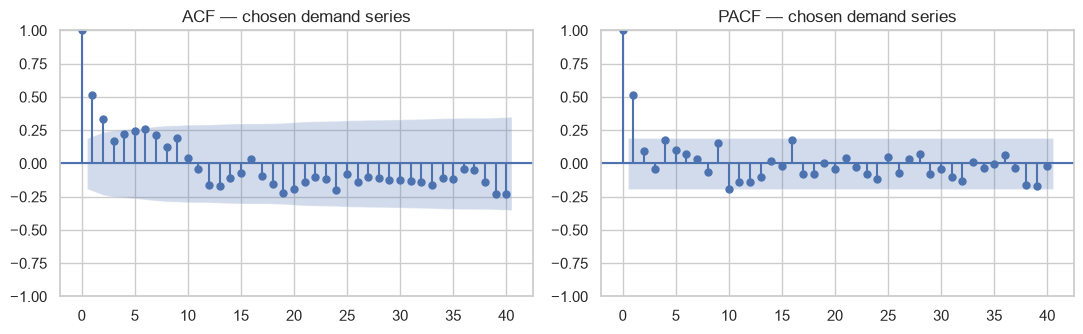

Top countries by units:


,units
Country,
United Kingdom,9383244
Netherlands,383977
EIRE,340289
France,275287
Denmark,237925
Germany,227983
Australia,104090
Sweden,88650
Switzerland,52884


In [5]:
stl_period = SEASONAL_PERIOD
if len(y_full) < 2 * stl_period + 1:
    stl_period = 7
    print(f"Series shorter than 2×{SEASONAL_PERIOD}; using STL period={stl_period}")

stl = STL(y_full.astype(float), period=stl_period, robust=True)
stl_res = stl.fit()
fig = stl_res.plot()
fig.set_size_inches(11, 7)
fig.suptitle(f"STL decomposition ({GRAIN}, period={stl_period})", y=1.01)
show_plot()

adf_stat, adf_p, *_ = adfuller(y_full.astype(float), autolag="AIC")
print(f"ADF statistic={adf_stat:.4f}, p-value={adf_p:.4g}")
if adf_p < 0.05:
    print("Reject H0 of unit root → series looks stationary (at 5%).")
else:
    print("Fail to reject unit root → integration/trend may be present.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[0])
plot_pacf(
    y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[1], method="ywm"
)
axes[0].set_title("ACF — chosen demand series")
axes[1].set_title("PACF — chosen demand series")
show_plot()

if "Country" in df.columns:
    top_c = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)
    print("Top countries by units:")
    display(top_c.to_frame("units"))

## 4. Target series + time-ordered holdout

Grain=weekly | H=8 | seasonal_period candidate=52
Train: 2009-12-06 → 2011-10-16 (n=98)
Test : 2011-10-23 → 2011-12-11 (n=8)
Train mean demand: 102308.4 units / period
Test  mean demand: 174260.6 units / period


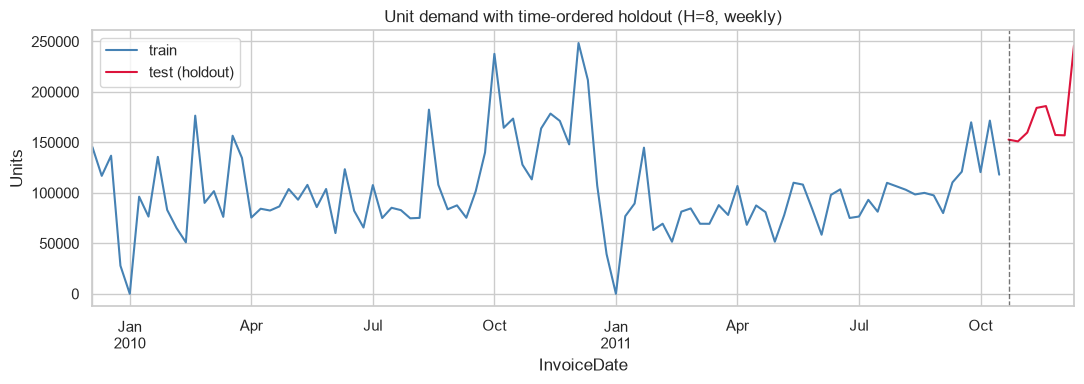

In [6]:
H = 8 if GRAIN == "weekly" else 28
if len(y_full) <= H + 20:
    H = max(4, len(y_full) // 5)
    print(f"Short series — reducing H to {H}")

y = y_full.astype(float).copy()
y.name = "demand"
y_train = y.iloc[:-H]
y_test = y.iloc[-H:]

print(f"Grain={GRAIN} | H={H} | seasonal_period candidate={SEASONAL_PERIOD}")
print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} (n={len(y_train)})")
print(f"Test : {y_test.index.min().date()} → {y_test.index.max().date()} (n={len(y_test)})")
print(f"Train mean demand: {y_train.mean():.1f} units / period")
print(f"Test  mean demand: {y_test.mean():.1f} units / period")

fig, ax = plt.subplots()
y_train.plot(ax=ax, label="train", color="steelblue")
y_test.plot(ax=ax, label="test (holdout)", color="crimson")
ax.axvline(y_test.index[0], color="k", ls="--", lw=1, alpha=0.6)
ax.set_title(f"Unit demand with time-ordered holdout (H={H}, {GRAIN})")
ax.set_ylabel("Units")
ax.legend()
show_plot()


def forecast_metrics(
    y_true: np.ndarray, y_pred: np.ndarray, y_train_arr: np.ndarray, m: int
) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train_arr = np.asarray(y_train_arr, dtype=float)
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    denom = np.maximum(np.abs(y_true), 1e-8)
    mape = float(np.mean(np.abs(err) / denom) * 100)
    m = max(1, min(m, len(y_train_arr) // 2))
    scale = np.mean(np.abs(y_train_arr[m:] - y_train_arr[:-m]))
    if not np.isfinite(scale) or scale < 1e-8:
        scale = np.mean(np.abs(np.diff(y_train_arr))) + 1e-8
    mase = float(mae / scale)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MASE": mase}

## 5. Part 1 — PyCaret survey (MASE-ranked)

Same OOP API as notebook 1:
`TimeSeriesExperiment` → `fit(y_train)` → `compare_models(sort="MASE")`
→ `CompareResult.best / .leaderboard / .ranked_ids`.

In [7]:
from pycaret.time_series import TimeSeriesExperiment

if GRAIN == "weekly":
    sp_for_exp = 4  # practical short cycle for survey speed
else:
    sp_for_exp = 7
if len(y_train) < 2 * sp_for_exp:
    sp_for_exp = max(1, len(y_train) // 4)
print(
    f"PyCaret seasonal_period={sp_for_exp} "
    f"(EDA used ~{SEASONAL_PERIOD}; survey uses a faster cycle)"
)

exp = TimeSeriesExperiment(
    fh=H,
    session_id=SEED,
    fold=2,
    fold_strategy="expanding",
    seasonal_period=sp_for_exp,
    verbose=False,
    n_jobs=1,
)
exp.fit(y_train)

print("Registered models (sample):")
try:
    display(exp.models())
except Exception as exc:  # noqa: BLE001
    print("models() unavailable:", exc)

SURVEY_INCLUDE = [
    "naive",
    "snaive",
    "grand_means",
    "polytrend",
    "arima",
    "exp_smooth",
    "ets",
    "theta",
    "croston",
]
print(f"\nRunning compare_models(sort='MASE', include={SURVEY_INCLUDE})…")
compare_result = exp.compare_models(
    sort="MASE",
    include=SURVEY_INCLUDE,
    turbo=True,
    n_select=1,
    verbose=False,
)

leaderboard = compare_result.leaderboard.copy()
if "MASE" in leaderboard.columns:
    leaderboard_valid = leaderboard.dropna(subset=["MASE"]).reset_index(drop=True)
else:
    leaderboard_valid = leaderboard

print("\n=== PyCaret leaderboard (MASE-sorted; lower is better) ===")
display(leaderboard_valid)

if leaderboard_valid.empty or compare_result.best is None:
    raise RuntimeError(f"PyCaret compare_models failed. Raw leaderboard:\n{leaderboard}")

winner_id = str(compare_result.ranked_ids[0])
winner_row = leaderboard_valid.iloc[0]
print(f"\n>>> PYCARET WINNER: {winner_id}")
print(winner_row.to_string())

PyCaret seasonal_period=4 (EDA used ~52; survey uses a faster cycle)


Registered models (sample):


,Name,Reference,Turbo
ID,,,
naive,Naive Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
grand_means,Grand Means Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
polytrend,Polynomial Trend Forecaster,sktime.forecasting.trend._polynomial_trend_for...,True
arima,ARIMA,sktime.forecasting.arima._pmdarima.ARIMA,True
auto_arima,Auto ARIMA,sktime.forecasting.arima._pmdarima.AutoARIMA,True
exp_smooth,Exponential Smoothing,sktime.forecasting.exp_smoothing.ExponentialSm...,True
ets,ETS,sktime.forecasting.ets.AutoETS,True
theta,Theta Forecaster,sktime.forecasting.theta.ThetaForecaster,True
croston,Croston,sktime.forecasting.croston.Croston,True



Running compare_models(sort='MASE', include=['naive', 'snaive', 'grand_means', 'polytrend', 'arima', 'exp_smooth', 'ets', 'theta', 'croston'])…



=== PyCaret leaderboard (MASE-sorted; lower is better) ===


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,COVERAGE
0,arima,1.4841,1.0620,63174.7338,65797.6238,0.6888,1.0628,-17.0475,1.0
1,grand_means,1.5015,1.0696,63873.6338,66240.8052,0.6977,1.0804,-17.6101,1.0
2,theta,2.1043,1.4883,89693.0102,92298.2334,0.9940,1.8259,-33.1397,1.0
3,naive,3.6555,2.6771,155956.7537,166118.3086,1.7155,1.9252,-107.2635,1.0



>>> PYCARET WINNER: arima
Model            arima
MASE            1.4841
RMSSE            1.062
MAE         63174.7338
RMSE        65797.6238
MAPE            0.6888
SMAPE           1.0628
R2            -17.0475
COVERAGE           1.0


## 6. Part 1b — Native reimplementation of the winner

Native model: pmdarima auto_arima (1, 0, 0) seasonal=(0, 0, 0, 4)
Holdout point forecast (first 5): [110032.5, 106192.9, 104356.7, 103478.5, 103058.5]


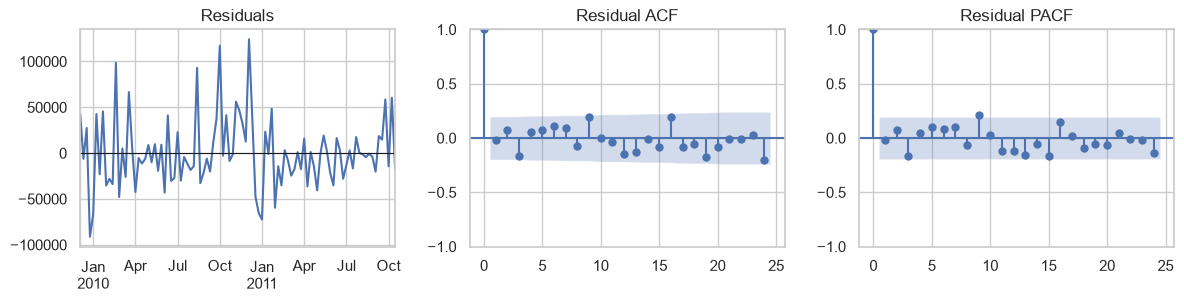

Ljung-Box on residuals:


,lb_stat,lb_pvalue
10,11.065461,0.352441


p=0.3524 → no strong evidence of leftover residual autocorrelation.


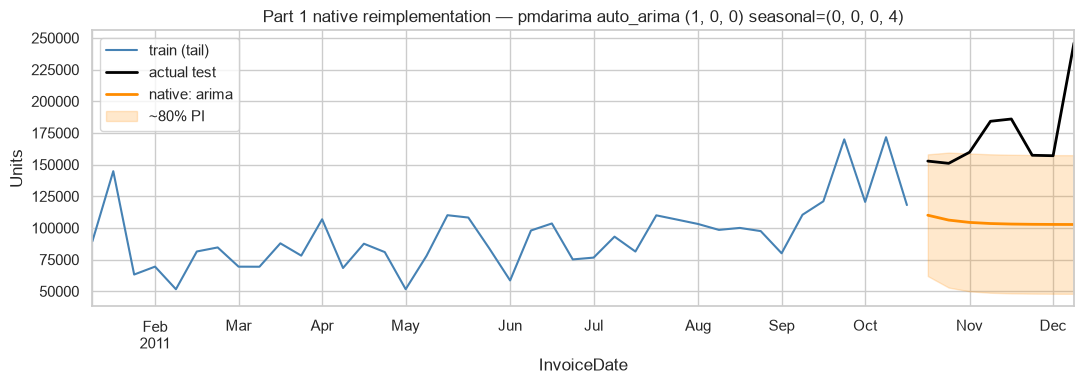

Native holdout metrics: {'MAE': 69828.8455, 'RMSE': 76435.7719, 'MAPE': 38.5213, 'MASE': 1.8253}


In [8]:
def fit_native_winner(model_id: str, train: pd.Series, h: int, seasonal_period: int):
    mid = model_id.lower()
    train_vals = train.astype(float)

    if mid in {"auto_arima", "arima"}:
        sp = seasonal_period if len(train_vals) >= 2 * seasonal_period else 1
        seasonal = sp > 1
        model = auto_arima(
            train_vals,
            seasonal=seasonal,
            m=sp if seasonal else 1,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False,
            random_state=SEED,
            n_jobs=1,
        )
        fc = model.predict(n_periods=h, return_conf_int=True, alpha=0.2)
        pred = np.asarray(fc[0], dtype=float)
        lower = np.asarray(fc[1][:, 0], dtype=float)
        upper = np.asarray(fc[1][:, 1], dtype=float)
        residuals = pd.Series(model.resid(), index=train_vals.index[-len(model.resid()) :])
        label = f"pmdarima auto_arima {model.order} seasonal={model.seasonal_order}"
        return pred, lower, upper, residuals, label, model

    if mid in {"exp_smooth", "ets"}:
        use_seasonal = len(train_vals) >= 2 * seasonal_period and seasonal_period > 1
        hw = ExponentialSmoothing(
            train_vals,
            trend="add",
            seasonal="add" if use_seasonal else None,
            seasonal_periods=seasonal_period if use_seasonal else None,
            initialization_method="estimated",
        ).fit(optimized=True)
        pred = np.asarray(hw.forecast(h), dtype=float)
        resid = (train_vals - hw.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        label = f"statsmodels ExponentialSmoothing (seasonal={use_seasonal})"
        return pred, pred - z * sigma, pred + z * sigma, resid, label, hw

    if mid == "theta":
        hw = ExponentialSmoothing(
            train_vals, trend="add", seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
        pred = np.asarray(hw.forecast(h), dtype=float)
        resid = (train_vals - hw.fittedvalues).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        label = "Theta-analogue via additive Holt (statsmodels)"
        return pred, pred - z * sigma, pred + z * sigma, resid, label, hw

    if mid == "naive":
        last = float(train_vals.iloc[-1])
        pred = np.full(h, last)
        resid = train_vals.diff().dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        return pred, pred - z * sigma, pred + z * sigma, resid, "Naive (last value)", None

    if mid == "snaive":
        sp = seasonal_period if seasonal_period > 1 else 7
        if len(train_vals) < sp:
            sp = max(1, len(train_vals) // 2)
        hist = train_vals.values
        pred = np.array([hist[-sp + (i % sp)] for i in range(h)], dtype=float)
        if len(hist) > sp:
            resid = pd.Series(hist[sp:] - hist[:-sp])
        else:
            resid = train_vals.diff().dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        return (
            pred,
            pred - z * sigma,
            pred + z * sigma,
            resid,
            f"Seasonal naive (period={sp})",
            None,
        )

    if mid in {"grand_means", "polytrend"}:
        if mid == "grand_means":
            level = float(train_vals.mean())
            pred = np.full(h, level)
            fitted = pd.Series(level, index=train_vals.index)
            label = "Grand mean"
        else:
            x = np.arange(len(train_vals))
            coef = np.polyfit(x, train_vals.values, deg=1)
            pred = np.polyval(coef, np.arange(len(train_vals), len(train_vals) + h))
            fitted = pd.Series(np.polyval(coef, x), index=train_vals.index)
            label = "Linear trend (poly deg=1)"
        resid = (train_vals - fitted).dropna()
        sigma = float(resid.std(ddof=1)) if len(resid) else 1.0
        z = stats.norm.ppf(0.9)
        return pred, pred - z * sigma, pred + z * sigma, resid, label, None

    if mid == "croston":
        print(f"Native Croston not implemented; falling back to pmdarima for id={mid}")
        return fit_native_winner("auto_arima", train, h, seasonal_period)

    print(
        f"Winner '{model_id}' mapped to pmdarima auto_arima as classical counterpart."
    )
    pred, lower, upper, residuals, label, model = fit_native_winner(
        "auto_arima", train, h, seasonal_period
    )
    return pred, lower, upper, residuals, f"mapped({model_id})→{label}", model


native_pred, native_lo, native_hi, native_resid, native_label, native_model = (
    fit_native_winner(winner_id, y_train, H, sp_for_exp)
)
native_fc = pd.Series(
    np.clip(native_pred, 0, None), index=y_test.index, name="native_forecast"
)
native_lo_s = pd.Series(native_lo, index=y_test.index)
native_hi_s = pd.Series(native_hi, index=y_test.index)

print(f"Native model: {native_label}")
print(f"Holdout point forecast (first 5): {native_fc.head().round(1).tolist()}")

if native_resid is not None and len(native_resid.dropna()) > 10:
    resid = native_resid.dropna()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    resid.plot(ax=axes[0], title="Residuals")
    axes[0].axhline(0, color="k", lw=0.8)
    plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[1])
    plot_pacf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[2], method="ywm")
    axes[1].set_title("Residual ACF")
    axes[2].set_title("Residual PACF")
    show_plot()

    lb = acorr_ljungbox(resid, lags=[min(10, len(resid) // 5)], return_df=True)
    print("Ljung-Box on residuals:")
    display(lb)
    p_lb = float(lb["lb_pvalue"].iloc[0])
    if p_lb < 0.05:
        print(f"p={p_lb:.4f} → residual structure remains; model may be under-specified.")
    else:
        print(f"p={p_lb:.4f} → no strong evidence of leftover residual autocorrelation.")
else:
    print("Residual diagnostics skipped (insufficient residual series).")

fig, ax = plt.subplots(figsize=(11, 4))
y_train.iloc[-min(40, len(y_train)) :].plot(ax=ax, label="train (tail)", color="steelblue")
y_test.plot(ax=ax, label="actual test", color="black", lw=2)
native_fc.plot(ax=ax, label=f"native: {winner_id}", color="darkorange", lw=2)
ax.fill_between(
    y_test.index, native_lo_s, native_hi_s, color="darkorange", alpha=0.2, label="~80% PI"
)
ax.set_title(f"Part 1 native reimplementation — {native_label}")
ax.set_ylabel("Units")
ax.legend()
show_plot()

mase_period = sp_for_exp if len(y_train) > sp_for_exp + 5 else 1
metrics_native = forecast_metrics(
    y_test.values, native_fc.values, y_train.values, mase_period
)
print("Native holdout metrics:", {k: round(v, 4) for k, v in metrics_native.items()})

## 7. Part 2 — Google TimesFM 2.5 (zero-shot)

Zero-shot means **no weight updates** on Online Retail II. The train window is
still used fully as **context** at inference time.

Loading TimesFM 2.5 200M (PyTorch) from Hugging Face…


Context length used: 98 (max_context=98)
TimesFM point forecast (first 5): [124999.203125, 123284.203125, 134309.09375, 148270.59375, 157549.59375]


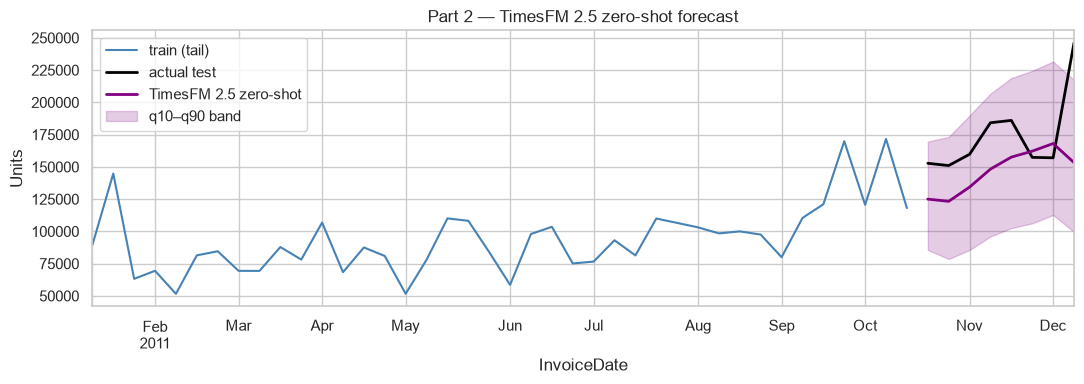

TimesFM holdout metrics: {'MAE': 31731.9473, 'RMSE': 40346.5195, 'MAPE': 16.8794, 'MASE': 0.8295}


In [9]:
torch.set_float32_matmul_precision("high")

print("Loading TimesFM 2.5 200M (PyTorch) from Hugging Face…")
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
context_len = int(min(len(y_train), 1024))
tfm.compile(
    timesfm.ForecastConfig(
        max_context=context_len,
        max_horizon=H,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        per_core_batch_size=32,
    )
)

context = y_train.values.astype(np.float32)
point, quantiles = tfm.forecast(horizon=H, inputs=[context])
tfm_point = np.clip(point[0], 0, None)
tfm_lo = quantiles[0, :, 1]
tfm_hi = quantiles[0, :, 9]
tfm_fc = pd.Series(tfm_point, index=y_test.index, name="timesfm")
tfm_lo_s = pd.Series(tfm_lo, index=y_test.index)
tfm_hi_s = pd.Series(tfm_hi, index=y_test.index)

print(f"Context length used: {len(context)} (max_context={context_len})")
print(f"TimesFM point forecast (first 5): {tfm_fc.head().round(1).tolist()}")

fig, ax = plt.subplots(figsize=(11, 4))
y_train.iloc[-min(40, len(y_train)) :].plot(ax=ax, label="train (tail)", color="steelblue")
y_test.plot(ax=ax, label="actual test", color="black", lw=2)
tfm_fc.plot(ax=ax, label="TimesFM 2.5 zero-shot", color="purple", lw=2)
ax.fill_between(
    y_test.index, tfm_lo_s, tfm_hi_s, color="purple", alpha=0.2, label="q10–q90 band"
)
ax.set_title("Part 2 — TimesFM 2.5 zero-shot forecast")
ax.set_ylabel("Units")
ax.legend()
show_plot()

metrics_tfm = forecast_metrics(y_test.values, tfm_fc.values, y_train.values, mase_period)
print("TimesFM holdout metrics:", {k: round(v, 4) for k, v in metrics_tfm.items()})

## 8. Side-by-side comparison

=== Holdout metrics (identical definitions) ===


,MAE,RMSE,MAPE,MASE
Native (arima),69828.8455,76435.7719,38.5213,1.8253
TimesFM 2.5 zero-shot,31731.9473,40346.5195,16.8794,0.8295



Lower MASE wins on this holdout → TimesFM 2.5 zero-shot
Native MASE=1.8253 vs TimesFM MASE=0.8295


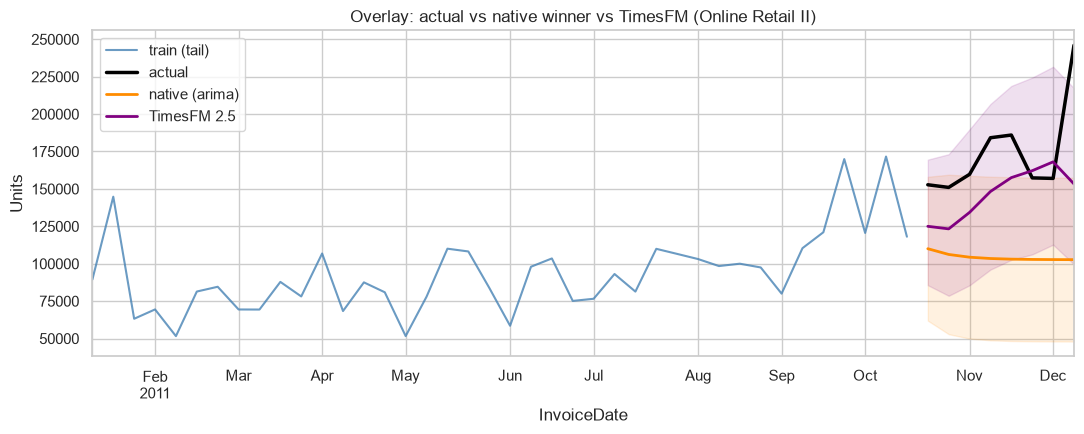


=== Why this result is plausible ===
TimesFM 2.5 zero-shot achieved lower MASE than the native reimplementation of arima. Foundation-model priors help when local seasonality is noisy or the classical form is misspecified. History was still provided as context (len=98).


In [10]:
comparison = pd.DataFrame(
    {
        f"Native ({winner_id})": metrics_native,
        "TimesFM 2.5 zero-shot": metrics_tfm,
    }
).T[["MAE", "RMSE", "MAPE", "MASE"]]
print("=== Holdout metrics (identical definitions) ===")
display(comparison.round(4))

best_mase_model = comparison["MASE"].idxmin()
print(f"\nLower MASE wins on this holdout → {best_mase_model}")
print(
    f"Native MASE={metrics_native['MASE']:.4f} vs TimesFM MASE={metrics_tfm['MASE']:.4f}"
)

fig, ax = plt.subplots(figsize=(11, 4.5))
y_train.iloc[-min(40, len(y_train)) :].plot(
    ax=ax, label="train (tail)", color="steelblue", alpha=0.8
)
y_test.plot(ax=ax, label="actual", color="black", lw=2.5)
native_fc.plot(ax=ax, label=f"native ({winner_id})", color="darkorange", lw=2)
tfm_fc.plot(ax=ax, label="TimesFM 2.5", color="purple", lw=2)
ax.fill_between(y_test.index, native_lo_s, native_hi_s, color="darkorange", alpha=0.12)
ax.fill_between(y_test.index, tfm_lo_s, tfm_hi_s, color="purple", alpha=0.12)
ax.set_title("Overlay: actual vs native winner vs TimesFM (Online Retail II)")
ax.set_ylabel("Units")
ax.legend()
show_plot()

native_better = metrics_native["MASE"] < metrics_tfm["MASE"]
print("\n=== Why this result is plausible ===")
if native_better:
    print(
        f"The PyCaret-selected native model ({winner_id} → {native_label}) achieved "
        f"lower MASE on this Online Retail II {GRAIN} series. Classical models can "
        f"lock onto domain-specific seasonality when the series is regular enough "
        f"(n_train={len(y_train)}, H={H}). TimesFM still consumed the full train "
        f"context zero-shot, without series-specific coefficient fitting."
    )
else:
    print(
        f"TimesFM 2.5 zero-shot achieved lower MASE than the native reimplementation of "
        f"{winner_id}. Foundation-model priors help when local seasonality is noisy or "
        f"the classical form is misspecified. History was still provided as context "
        f"(len={len(y_train)})."
    )

## 9. Inventory-planning takeaway

In [11]:
mean_actual = float(y_test.mean())
if native_better:
    plan_fc, plan_lo, plan_hi, plan_name = (
        native_fc,
        native_lo_s,
        native_hi_s,
        f"native/{winner_id}",
    )
else:
    plan_fc, plan_lo, plan_hi, plan_name = tfm_fc, tfm_lo_s, tfm_hi_s, "TimesFM 2.5"

avg_point = float(plan_fc.mean())
avg_lo = float(plan_lo.mean())
avg_hi = float(plan_hi.mean())
band_width = avg_hi - avg_lo
period_word = "week" if GRAIN == "weekly" else "day"

print("=== Inventory-facing summary (from this run) ===")
print(f"Grain: {GRAIN} | holdout periods: {H}")
print(f"Actual mean demand in holdout: {mean_actual:.1f} units / period")
print(f"Preferred model for narrative: {plan_name}")
print(f"  mean point forecast: {avg_point:.1f}")
print(f"  mean lower band:     {avg_lo:.1f}")
print(f"  mean upper band:     {avg_hi:.1f}")
print(f"  mean band width:     {band_width:.1f}")
print()
print(
    f"If replenishment is planned around ~{avg_point:.0f} units per {period_word}, "
    f"the predictive band (~{avg_lo:.0f}–{avg_hi:.0f}) is a practical envelope for a "
    f"service-minded buffer. Covering toward the upper end reduces stockout risk when "
    f"demand spikes (at the cost of more on-hand stock). Relative to a pure point order "
    f"of {avg_point:.0f}, targeting closer to {avg_hi:.0f} is the more conservative "
    f"posture suggested by this forecast distribution — directional guidance only, not "
    f"a full EOQ/safety-stock formula."
)
print()
print("Metric recap:")
display(comparison.round(4))
print(f"\nGranularity decision was: {decision_reason}")
print(f"PyCaret winner: {winner_id} | Native label: {native_label}")
print("Notebook 02 complete.")

=== Inventory-facing summary (from this run) ===
Grain: weekly | holdout periods: 8
Actual mean demand in holdout: 174260.6 units / period
Preferred model for narrative: TimesFM 2.5
  mean point forecast: 146494.9
  mean lower band:     95876.5
  mean upper band:     203929.8
  mean band width:     108053.3

If replenishment is planned around ~146495 units per week, the predictive band (~95877–203930) is a practical envelope for a service-minded buffer. Covering toward the upper end reduces stockout risk when demand spikes (at the cost of more on-hand stock). Relative to a pure point order of 146495, targeting closer to 203930 is the more conservative posture suggested by this forecast distribution — directional guidance only, not a full EOQ/safety-stock formula.

Metric recap:


,MAE,RMSE,MAPE,MASE
Native (arima),69828.8455,76435.7719,38.5213,1.8253
TimesFM 2.5 zero-shot,31731.9473,40346.5195,16.8794,0.8295



Granularity decision was: Daily series has 18.3% zero-demand days and CV=0.87 vs weekly CV=0.43. Weekly aggregation is more stable for planning.
PyCaret winner: arima | Native label: pmdarima auto_arima (1, 0, 0) seasonal=(0, 0, 0, 4)
Notebook 02 complete.
